# Regresión Polinomial con Descenso en Gradiente

## 1. Modelo

Consideramos un modelo de **regresión polinomial de grado 2** con una sola variable explicativa:

$$
h(x) = b_0 + b_1 x + b_2 x^2
$$

donde:
- $b_0$ es el intercepto
- $b_1$ es el coeficiente lineal
- $b_2$ es el coeficiente cuadrático

---

## 2. Función de costo (Error Cuadrático Medio)

Dado un conjunto de datos $(\{(x^{(i)}, y^{(i)})\}_{i=1}^m\)$, usamos la función de costo MSE:

$$
J(b_0,b_1,b_2) = \frac{1}{2m} \sum_{i=1}^{m} \left( h(x^{(i)}) - y^{(i)} \right)^2
$$

El factor \(\frac{1}{2}\) se incluye para simplificar las derivadas.

---

## 3. Sustitución del modelo en la función de costo

$$
J = \frac{1}{2m} \sum_{i=1}^{m}
\left(
b_0 + b_1 x^{(i)} + b_2 (x^{(i)})^2 - y^{(i)}
\right)^2
$$

---

## 4. Descenso en gradiente

El descenso en gradiente actualiza cada parámetro en la dirección opuesta al gradiente:

$$
b_j \leftarrow b_j - \alpha \frac{\partial J}{\partial b_j}
$$

donde \(\alpha\) es el learning rate.

---

## 5. Derivada parcial respecto a $b_2$

Calculamos la derivada de la función de costo:

$$
\frac{\partial J}{\partial b_2}
=
\frac{1}{m} \sum_{i=1}^{m}
\left(
h(x^{(i)}) - y^{(i)}
\right)
\cdot (x^{(i)})^2
$$

Esto ocurre porque:

$$
\frac{\partial h(x^{(i)})}{\partial b_2} = (x^{(i)})^2
$$

---

## 6. Regla de actualización para \(b_2\) (Batch Gradient Descent)

$$
\boxed{
b_2 \leftarrow
b_2
-
\alpha
\frac{1}{m}
\sum_{i=1}^{m}
\left(
h(x^{(i)}) - y^{(i)}
\right)
(x^{(i)})^2
}
$$

---

## 7. Caso especial: Stochastic Gradient Descent (SGD)

Si se usa **una sola observación** por iteración, la actualización se convierte en:

$$
b_2 \leftarrow
b_2
-
\alpha
\left(
h(x^{(i)}) - y^{(i)}
\right)
(x^{(i)})^2
$$

En este caso **no aparece la suma ni el factor $1/m$**.

---

## 8. Interpretación económica / geométrica

- El término $(x^{(i)})^2$ amplifica el gradiente para valores grandes de $x$
- Sin **feature scaling**, el gradiente puede explotar
- El learning rate efectivo depende tanto de \(\alpha\) como de la escala de $x^2$

Por esta razón, la regresión polinomial **requiere normalización** para que el descenso en gradiente sea estable.


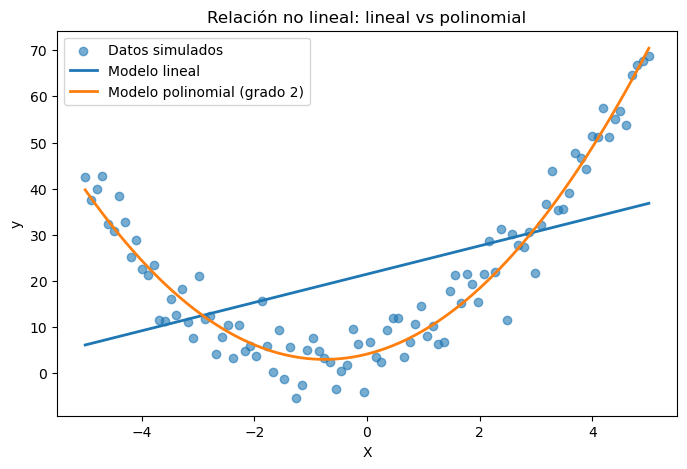

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# -----------------------
# 1. Simular datos
# -----------------------
np.random.seed(42)

n = 100
X = np.linspace(-5, 5, n).reshape(-1, 1)

# Relación verdadera (no lineal)
y_true = 2 * X[:, 0]**2 + 3 * X[:, 0] + 5

# Ruido
noise = np.random.normal(0, 5, size=n)
y = y_true + noise

# -----------------------
# 2. Modelo lineal
# -----------------------
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_lin_pred = lin_reg.predict(X)

# -----------------------
# 3. Modelo polinomial grado 2
# -----------------------
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_poly_pred = poly_reg.predict(X_poly)

# -----------------------
# 4. Gráfica
# -----------------------
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, label="Datos simulados")
plt.plot(X, y_lin_pred, linewidth=2, label="Modelo lineal")
plt.plot(X, y_poly_pred, linewidth=2, label="Modelo polinomial (grado 2)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Relación no lineal: lineal vs polinomial")
plt.legend()
plt.show()


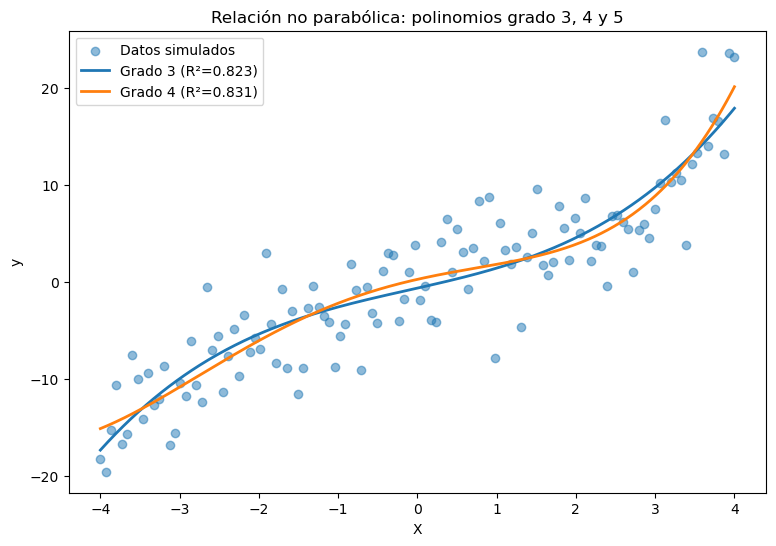

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------
# 1) Simular datos NO parabólicos
# -----------------------
np.random.seed(42)

n = 120
X = np.linspace(-4, 4, n).reshape(-1, 1)

# Relación verdadera: cúbica + componente no polinómica
y_true = (
    0.5 * X[:, 0]**3
    - 2 * X[:, 0]
    + 5 * np.sin(X[:, 0])
)

y = y_true + np.random.normal(0, 4, size=n)

X_grid = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

# -----------------------
# 2) Ajustar grados 3, 4, 5
# -----------------------
degrees = [3, 4]

plt.figure(figsize=(9, 6))
plt.scatter(X, y, alpha=0.5, label="Datos simulados")

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    Xg_poly = poly.transform(X_grid)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)
    y_grid_pred = model.predict(Xg_poly)

    r2 = r2_score(y, y_pred)
    plt.plot(X_grid, y_grid_pred, linewidth=2, label=f"Grado {d} (R²={r2:.3f})")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Relación no parabólica: polinomios grado 3, 4 y 5")
plt.legend()
plt.show()
